# 01 - Titanic EDA: profile, clean, and tell the data story

Module 2, Part A. This notebook is the **only** place the raw dataset is loaded
(`sns.load_dataset('titanic')`). It is saved straight away as `titanic.csv`, the committed offline
fallback, and `02_modeling.ipynb` continues from that same file.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG / name, dpi=110, bbox_inches="tight")

## Task 1 - Load once, save the offline fallback, profile

`sns.load_dataset` needs internet the first time it runs. If that fails (for example, grading
offline), the committed `titanic.csv` is read instead. Either way this is the module's single
load of the raw data.

In [2]:
try:
    df = sns.load_dataset("titanic")          # the one and only raw load
    source = "sns.load_dataset('titanic')"
except Exception as exc:                      # offline: fall back to the committed copy
    df = pd.read_csv("titanic.csv")
    source = f"titanic.csv (offline fallback: {type(exc).__name__})"

df.to_csv("titanic.csv", index=False)         # committed offline fallback
print("Loaded from:", source)
print("Shape:", df.shape)

Loaded from: sns.load_dataset('titanic')
Shape: (891, 15)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = (pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
                  .query("n_missing > 0")
                  .sort_values("pct_missing", ascending=False))
missing_report

,n_missing,pct_missing
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


In [7]:
balance = df["survived"].value_counts().rename(index={0: "died (0)", 1: "survived (1)"})
print(balance.to_string())
print((df["survived"].value_counts(normalize=True) * 100).round(2).rename("pct").to_string())

survived
died (0)        549
survived (1)    342
survived
0    61.62
1    38.38


**Profile summary.** The dataset has 891 rows and 15 columns. Four columns have missing values:
`deck` **77.22%**, `age` **19.87%**, `embarked` **0.22%** and `embark_town` **0.22%**
(`embarked` and `embark_town` are missing on the same 2 rows).
The target is imbalanced: **549 died (61.62%)** and **342 survived (38.38%)**, roughly 1.6 : 1.
That imbalance is why the modeling notebook uses a stratified split and compares imbalance
strategies.

## Task 2 - Missing-value handling (threshold rule)

Rule: **under 5% missing -> drop those rows; 5-30% -> impute; above 30% -> imputation is
unreliable, so either drop the column or encode "missing" as its own category.**

In [8]:
def strategy(pct):
    if pct < 5:
        return "drop rows (< 5%)"
    if pct <= 30:
        return "impute (5-30%)"
    return "too high to impute (> 30%): drop column or 'missing' category"

missing_report.assign(strategy=missing_report["pct_missing"].map(strategy))

,n_missing,pct_missing,strategy
deck,688,77.22,too high to impute (> 30%): drop column or 'mi...
age,177,19.87,impute (5-30%)
embarked,2,0.22,drop rows (< 5%)
embark_town,2,0.22,drop rows (< 5%)


**Decision for each affected column, citing the measured percentage and the rule:**

| Column | Measured missing | Rule band | Decision |
|---|---|---|---|
| `embarked` | 0.22% (2 rows) | < 5% -> drop rows | Drop the 2 rows. Losing 0.22% of the data costs nothing, and imputing a port would be a guess. |
| `embark_town` | 0.22% (the same 2 rows) | < 5% -> drop rows | Removed by the same row drop. |
| `age` | 19.87% (177 rows) | 5-30% -> impute | Impute the **median age within each (`pclass`, `sex`) group**. The median suits a right-skewed variable better than the mean. Grouping matters because age differs sharply by class: the median is 40 for 1st-class men and 21.5 for 3rd-class women. One global median (28) would pull every imputed passenger towards the middle. An `age_was_missing` flag keeps the imputation traceable. |
| `deck` | 77.22% (688 rows) | > 30% -> too high to impute | **Encode missing as its own category, `"Unknown"`**, rather than dropping the column. With over three quarters of values absent, any imputed deck would mostly be invented. But whether a deck is missing is itself informative: passengers with a recorded deck survived at **66.7%**, versus **29.9%** for "Unknown", because deck records exist mostly for 1st-class cabins. Dropping the column would throw that signal away, while guessing a deck would create false data. |

After cleaning: **889 rows, 0 missing values.**

In [9]:
clean = df.copy()

# embarked / embark_town: 0.22% missing each (the same 2 rows) -> drop rows
clean = clean.dropna(subset=["embarked", "embark_town"])

# age: 19.87% missing -> impute with the median age of the passenger's (pclass, sex) group
group_median = clean.groupby(["pclass", "sex"])["age"].transform("median")
clean["age_was_missing"] = clean["age"].isna()
clean["age"] = clean["age"].fillna(group_median)

# deck: 77.22% missing -> keep the column, encode missing as its own category "Unknown"
clean["deck"] = clean["deck"].astype("object").fillna("Unknown")

print("rows before:", len(df), "| rows after:", len(clean))
print("remaining missing values:", int(clean.isna().sum().sum()))
clean.groupby(["pclass", "sex"])["age"].median().rename("median age used for imputation")

rows before: 891 | rows after: 889
remaining missing values: 0


pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: median age used for imputation, dtype: float64

In [10]:
# does 'deck unknown' carry information? (why we kept it as a category)
clean.assign(deck_known=clean["deck"] != "Unknown").groupby("deck_known")[["survived"]].mean().round(3)

,survived
deck_known,
False,0.299
True,0.667


## Task 3 - Univariate analysis: `age` and `fare`

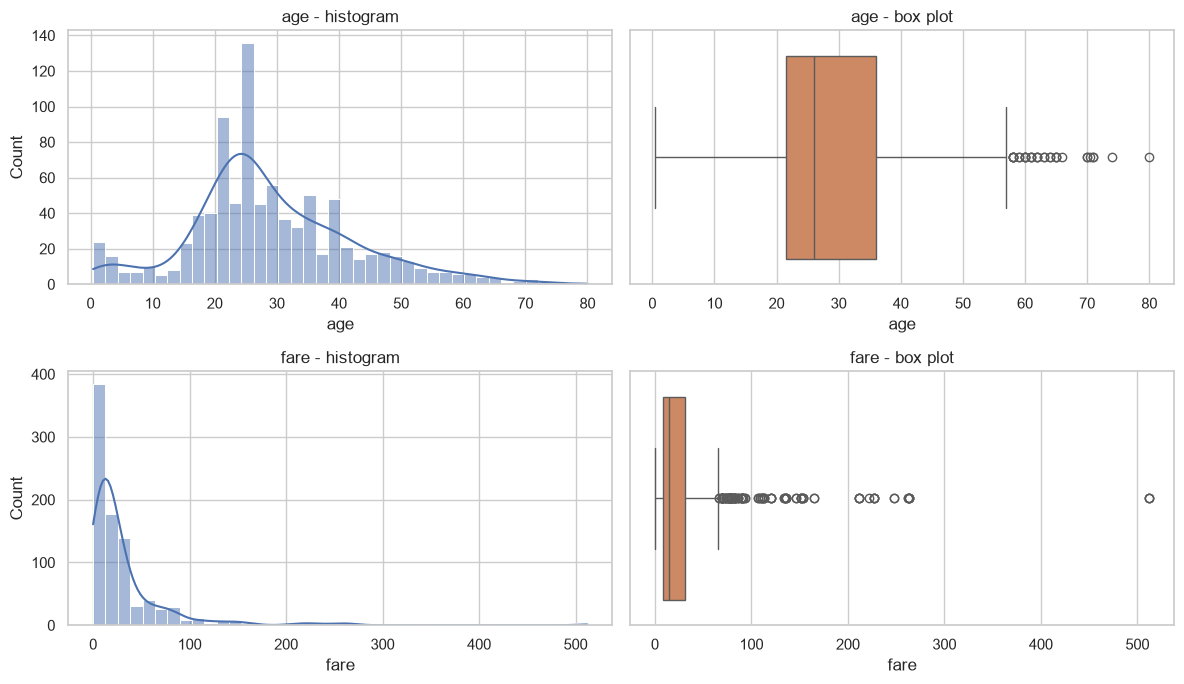

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, col in enumerate(["age", "fare"]):
    sns.histplot(clean[col], bins=40, kde=True, ax=axes[row, 0], color="#4C72B0")
    axes[row, 0].set_title(f"{col} - histogram")
    sns.boxplot(x=clean[col], ax=axes[row, 1], color="#DD8452")
    axes[row, 1].set_title(f"{col} - box plot")
fig.tight_layout()
save(fig, "01_univariate_age_fare.png")
plt.show()

In [12]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "lower_fence": lo, "upper_fence": hi,
            "n_below": int((s < lo).sum()), "n_above": int((s > hi).sum()),
            "n_outliers": int(((s < lo) | (s > hi)).sum())}

outliers = pd.DataFrame({
    "age (cleaned, imputed)": iqr_outliers(clean["age"]),
    "age (raw, non-missing only)": iqr_outliers(df["age"].dropna()),
    "fare (cleaned)": iqr_outliers(clean["fare"]),
}).T.round(2)
outliers

,Q1,Q3,IQR,lower_fence,upper_fence,n_below,n_above,n_outliers
"age (cleaned, imputed)",21.50,36.0,14.50,-0.25,57.75,0.0,32.0,32.0
"age (raw, non-missing only)",20.12,38.0,17.88,-6.69,64.81,0.0,11.0,11.0
fare (cleaned),7.90,31.0,23.10,-26.76,65.66,0.0,114.0,114.0


In [13]:
fare_stats = pd.Series({
    "mean": clean["fare"].mean(),
    "median": clean["fare"].median(),
    "mode": clean["fare"].mode().iloc[0],
    "skewness": clean["fare"].skew(),
}).round(3)
fare_stats

mean        32.097
median      14.454
mode         8.050
skewness     4.801
dtype: float64

**IQR outliers.**
- **`fare`:** **114 outliers**, all above the upper fence of 65.66. None fall below the lower
  fence, which is negative.
- **`age`:** **32 outliers** on the cleaned (imputed) column, all above 57.75. On the raw,
  non-missing ages there are only **11** (above 64.81). Imputing 177 values at group medians
  piles values up in the middle, which narrows the IQR, so more old passengers fall outside
  the fences. Both counts are shown so the effect of imputation is visible.

**Skewness of `fare`.** **mode (8.05) < median (14.45) < mean (32.10)**. That ordering is the
signature of a **right-skewed** distribution, and the skewness coefficient of +4.80 confirms it.
Most passengers paid low 3rd-class fares, while a long tail of expensive 1st-class tickets
(up to 512.33) pulls the mean far above the median.

## Task 4 - Bivariate analysis

Survival rates are computed with explicit boolean masks, combining conditions with `&`.

In [14]:
rate = lambda mask: clean.loc[mask, "survived"].mean()

by_sex = pd.Series({s: rate(clean["sex"] == s) for s in ["female", "male"]}, name="survival_rate")
by_class = pd.Series({c: rate(clean["pclass"] == c) for c in [1, 2, 3]}, name="survival_rate")
by_sex_class = pd.DataFrame(
    [{"sex": s, "pclass": c,
      "n": int(((clean["sex"] == s) & (clean["pclass"] == c)).sum()),
      "survival_rate": rate((clean["sex"] == s) & (clean["pclass"] == c))}
     for s in ["female", "male"] for c in [1, 2, 3]])

print("(a) by sex\n", by_sex.round(3).to_string(), "\n")
print("(b) by pclass\n", by_class.round(3).to_string(), "\n")
print("(c) by sex AND pclass\n", by_sex_class.round(3).to_string(index=False))

(a) by sex
 female    0.740
male      0.189 

(b) by pclass
 1    0.626
2    0.473
3    0.242 

(c) by sex AND pclass
    sex  pclass   n  survival_rate
female       1  92          0.967
female       2  76          0.921
female       3 144          0.500
  male       1 122          0.369
  male       2 108          0.157
  male       3 347          0.135


In [15]:
# an | example: women OR children (< 16) vs everyone else
women_or_children = (clean["sex"] == "female") | (clean["age"] < 16)
print(f"women or children: {rate(women_or_children):.3f}   adult men: {rate(~women_or_children):.3f}")

women or children: 0.716   adult men: 0.164


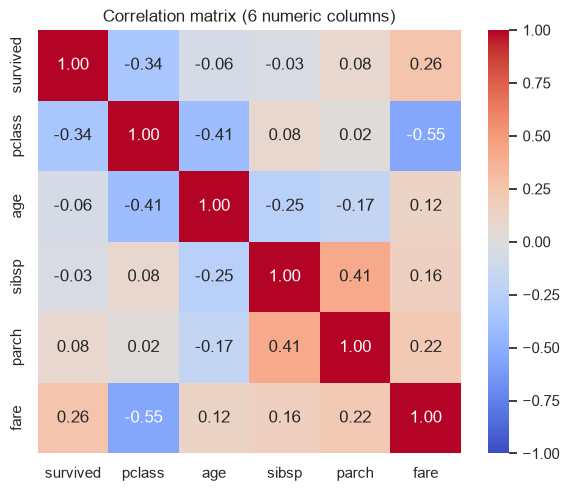

r  abs_r
pclass   fare   -0.548  0.548
sibsp    parch   0.415  0.415
pclass   age    -0.411  0.411
survived pclass -0.336  0.336
         fare    0.255  0.255
age      sibsp  -0.249  0.249
parch    fare    0.218  0.218
age      parch  -0.175  0.175
sibsp    fare    0.161  0.161
age      fare    0.120  0.120
survived parch   0.083  0.083
pclass   sibsp   0.082  0.082
survived age    -0.064  0.064
         sibsp  -0.034  0.034
pclass   parch   0.017  0.017

In [16]:
CORR_COLS = ["survived", "pclass", "age", "sibsp", "parch", "fare"]   # adult_male / alone excluded
corr = clean[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix (6 numeric columns)")
save(fig, "02_correlation_heatmap.png")
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))   # upper triangle, no diagonal
             .stack().dropna().rename("r").to_frame())
pairs["abs_r"] = pairs["r"].abs()
pairs.sort_values("abs_r", ascending=False).round(3)

**Survival rates (boolean masks):**
- **(a) by sex:** female **74.0%**, male **18.9%**.
- **(b) by class:** 1st **62.6%**, 2nd **47.3%**, 3rd **24.2%**.
- **(c) by sex and class:** female 1st **96.7%**, female 2nd **92.1%**, female 3rd **50.0%**,
  male 1st **36.9%**, male 2nd **15.7%**, male 3rd **13.5%**.
- Using `|`, "women or children under 16" survived at **71.6%**, versus **16.4%** for adult men.

**The two strongest correlations** (ranked by absolute off-diagonal r, from the sorted table above):
1. **`pclass` vs `fare`, r = -0.548.** Higher class *numbers* (cheaper classes) go with lower
   fares. The ticket price largely *is* the class, so these two columns carry overlapping
   information about wealth and status.
2. **`sibsp` vs `parch`, r = +0.415.** Passengers travelling with siblings or spouses also
   tended to travel with parents or children, meaning whole families travelled together.
   Both columns measure family size from different angles.

The next pair, `pclass` vs `age` (r = -0.411), is a very close third: older passengers were
more often in 1st class. Part of this correlation comes from our group-median imputation,
since the raw non-missing ages give r = -0.366. Among correlations with the target, `pclass`
is the strongest (r = -0.336).

## Task 5 - Multivariate data story: who survived, and why?

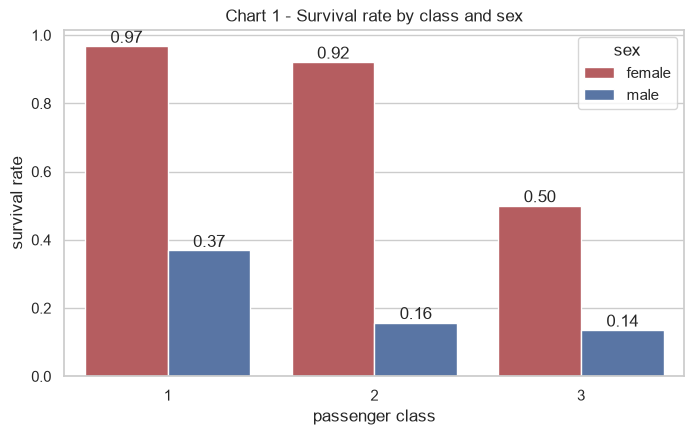

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=clean, x="pclass", y="survived", hue="sex", errorbar=None, ax=ax,
            palette={"female": "#C44E52", "male": "#4C72B0"})
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f")
ax.set(title="Chart 1 - Survival rate by class and sex", ylabel="survival rate", xlabel="passenger class")
save(fig, "03_story_class_sex.png")
plt.show()

**Interpretation.** Sex is the dominant factor. In every class, women survived at a far higher
rate than men (96.7% vs 36.9% in 1st class, 50.0% vs 13.5% in 3rd). Class is the second
factor: for both sexes, survival falls steadily from 1st to 3rd class. A 1st-class woman was
about seven times as likely to survive as a 3rd-class man, consistent with a
"women and children first" evacuation in which access to the boat deck favoured the upper
classes.

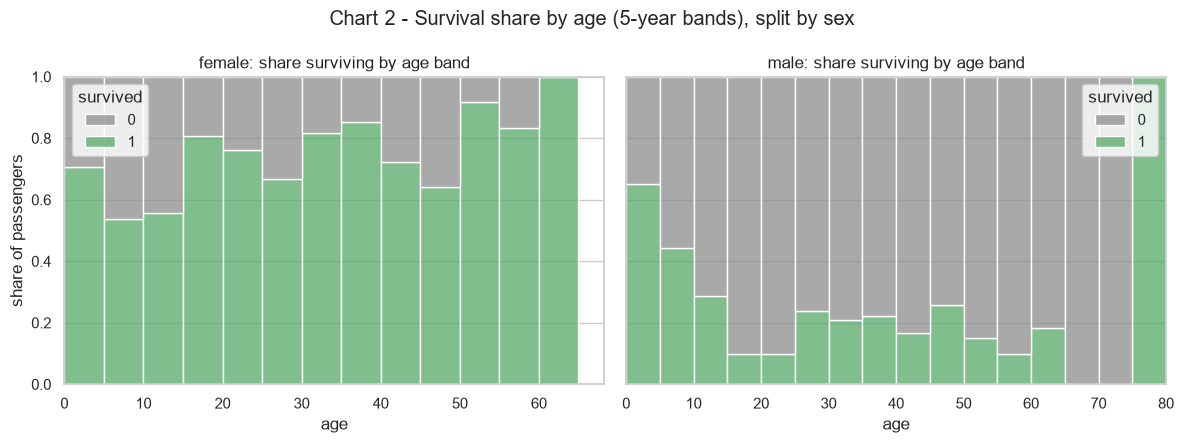

male children (<16) survival: 0.525
adult men (>=16) survival:    0.174


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
known_age = df.dropna(subset=["age"])        # raw ages only, so imputed values don't create a spike
for ax, sex in zip(axes, ["female", "male"]):
    sns.histplot(data=known_age[known_age["sex"] == sex], x="age", hue="survived", bins=range(0, 85, 5),
                 multiple="fill", ax=ax, palette={0: "#8C8C8C", 1: "#55A868"})
    ax.set(title=f"{sex}: share surviving by age band", ylabel="share of passengers")
fig.suptitle("Chart 2 - Survival share by age (5-year bands), split by sex")
fig.tight_layout()
save(fig, "04_story_age_sex.png")
plt.show()

child = known_age["age"] < 16
print("male children (<16) survival:", round(known_age.loc[child & (known_age.sex == "male"), "survived"].mean(), 3))
print("adult men (>=16) survival:   ", round(known_age.loc[~child & (known_age.sex == "male"), "survived"].mean(), 3))

**Interpretation.** The "children first" part of the rule shows up in the male panel. Boys
under 16 survived at **52.5%**, against **17.4%** for adult men, so being a child mattered
enormously for males. Among females, survival is high at almost every age, so age adds little
on top of sex. This chart uses only raw (non-imputed) ages, so the imputed median values
don't create an artificial spike.

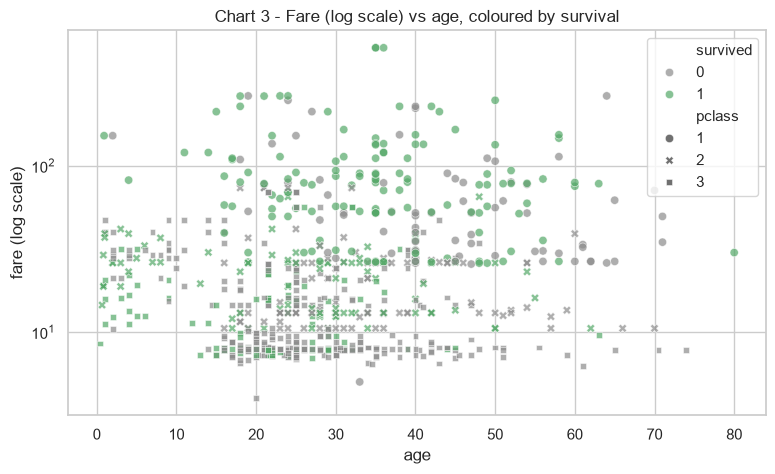

fare
Q1 cheapest    0.197
Q2             0.304
Q3             0.455
Q4 dearest     0.577
Name: survival rate by fare quartile, dtype: float64

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = clean[clean["fare"] > 0]
sns.scatterplot(data=plot_df, x="age", y="fare", hue="survived", style="pclass", alpha=0.7, ax=ax,
                palette={0: "#8C8C8C", 1: "#55A868"})
ax.set_yscale("log")
ax.set(title="Chart 3 - Fare (log scale) vs age, coloured by survival", ylabel="fare (log scale)")
save(fig, "05_story_fare_age.png")
plt.show()

fare_q = pd.qcut(clean["fare"], 4, labels=["Q1 cheapest", "Q2", "Q3", "Q4 dearest"])
clean.groupby(fare_q, observed=True)["survived"].mean().round(3).rename("survival rate by fare quartile")

**Interpretation.** Survivors (green) cluster in the upper part of the plot, at higher fares,
and 1st-class markers dominate that region. Fare quartiles make the gradient explicit:
survival rises from **19.7%** in the cheapest quartile to **57.7%** in the most expensive.
Fare works as a proxy for class and cabin location. Wealthier passengers were berthed closer
to the lifeboats and could reach them first. (Chart 3 leaves out the 15 zero-fare tickets
because the axis is logarithmic.)

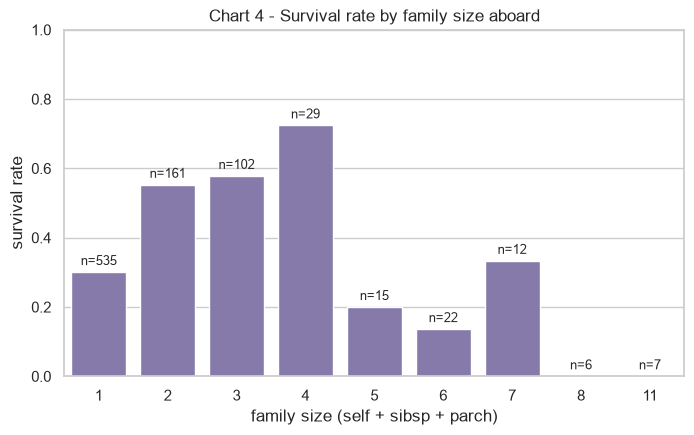

,n,survival_rate
family_size,,
1,535,0.301
2,161,0.553
3,102,0.578
4,29,0.724
5,15,0.200
6,22,0.136
7,12,0.333
8,6,0.000
11,7,0.000


In [20]:
clean["family_size"] = clean["sibsp"] + clean["parch"] + 1
fam = clean.groupby("family_size").agg(n=("survived", "size"), survival_rate=("survived", "mean"))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=fam.index, y=fam["survival_rate"], color="#8172B2", ax=ax)
for i, (n, r) in enumerate(zip(fam["n"], fam["survival_rate"])):
    ax.text(i, r + 0.02, f"n={n}", ha="center", fontsize=9)
ax.set(title="Chart 4 - Survival rate by family size aboard", xlabel="family size (self + sibsp + parch)",
       ylabel="survival rate", ylim=(0, 1))
save(fig, "06_story_family_size.png")
plt.show()
fam.round(3)

**Interpretation.** Family size has a non-linear effect. People travelling alone survived at
only **30.1%**. Small families of 2-4 did best, at **55-72%**: a companion could help, and
these groups often included women and children. Large families of 5 or more fared badly
(0-33%). They were mostly 3rd-class households that were hard to keep together and evacuate.
This is why `sibsp` and `parch` matter even though their straight-line correlation with
`survived` is weak (r = -0.03 and 0.08).

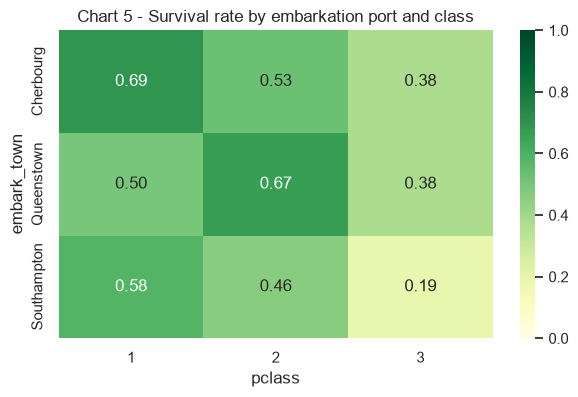

survival_rate               n_passengers          
pclass                  1      2      3            1    2    3
embark_town                                                   
Cherbourg           0.694  0.529  0.379           85   17   66
Queenstown          0.500  0.667  0.375            2    3   72
Southampton         0.583  0.463  0.190          127  164  353

In [21]:
pivot = clean.pivot_table(index="embark_town", columns="pclass", values="survived", aggfunc="mean")
counts = clean.pivot_table(index="embark_town", columns="pclass", values="survived", aggfunc="size")

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Chart 5 - Survival rate by embarkation port and class")
save(fig, "07_story_port_class.png")
plt.show()
pd.concat({"survival_rate": pivot.round(3), "n_passengers": counts}, axis=1)

**Interpretation.** Cherbourg passengers survived most often overall (55.4%, against 33.7%
for Southampton), but the heatmap shows that is largely a *class-mix* effect. 85 of
Cherbourg's 168 passengers were in 1st class, while Southampton's were mostly 3rd class.
Within the same class the gaps shrink (1st class: 69.4% Cherbourg vs 58.3% Southampton), and
Queenstown's cells rest on very few 1st/2nd-class passengers (2 and 3). The port of
embarkation is therefore mostly a stand-in for class, not an independent cause.

### The story in one paragraph

Survival on the Titanic was decided mostly by **who you were and where you were berthed**.
**Sex** is the strongest single factor (74% of women survived vs 19% of men), reflecting the
"women and children first" rule, and **childhood** protected boys too (52.5% vs 17.4% for
adult men). **Class**, and **fare** as its price tag, came second: survival fell from 63% (1st) to 47% (2nd) to
24% (3rd), and it tripled from the cheapest to the dearest fare quartile.
**Family size** helped in small groups and hurt in large ones. The **port of embarkation**
mostly reflects each port's class mix. These findings point the model towards `sex`,
`pclass`, `age`, `fare` and family variables as the key features.

## Task 6 - Exploratory z-score standardization check

`z = (x - mean) / std`, computed by hand on the full cleaned DataFrame. This is an EDA sanity
check only. The modeling notebook fits its own `StandardScaler` on the training split.

In [22]:
z = pd.DataFrame({f"{c}_z": (clean[c] - clean[c].mean()) / clean[c].std() for c in ["age", "fare"]})

summary = pd.DataFrame({
    "mean_before": clean[["age", "fare"]].mean().values,
    "std_before": clean[["age", "fare"]].std().values,
    "mean_after": z.mean().values,
    "std_after": z.std().values,
}, index=["age", "fare"]).round(4)
summary

,mean_before,std_before,mean_after,std_after
age,29.0654,13.2702,0.0,1.0
fare,32.0967,49.6975,0.0,1.0


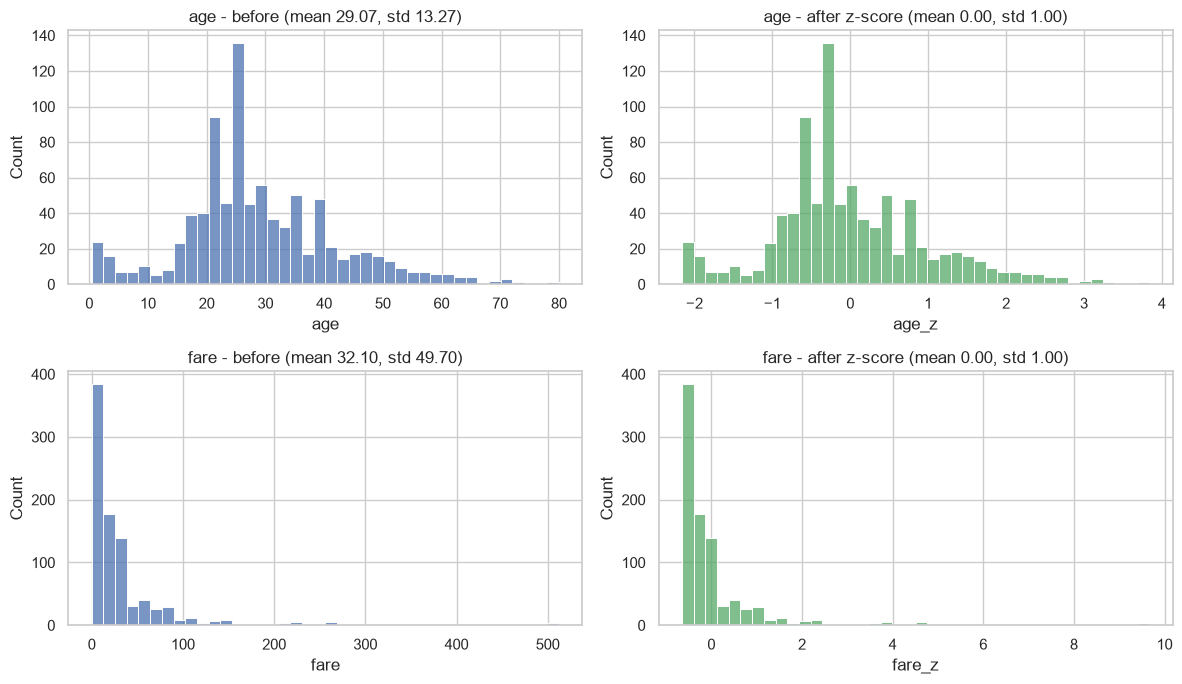

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, c in enumerate(["age", "fare"]):
    sns.histplot(clean[c], bins=40, ax=axes[row, 0], color="#4C72B0")
    axes[row, 0].set_title(f"{c} - before (mean {clean[c].mean():.2f}, std {clean[c].std():.2f})")
    sns.histplot(z[f"{c}_z"], bins=40, ax=axes[row, 1], color="#55A868")
    axes[row, 1].set_title(f"{c} - after z-score (mean {z[f'{c}_z'].mean():.2f}, std {z[f'{c}_z'].std():.2f})")
fig.tight_layout()
save(fig, "08_zscore_before_after.png")
plt.show()

**Before/after check.** Before scaling, `age` has mean 29.07 and std 13.27, and `fare` has
mean 32.10 and std 49.70. After `z = (x - mean) / std`, both columns have **mean 0.0000 and
std 1.0000**, which confirms the transformation. The histograms show the *shape* is unchanged:
`fare` is still strongly right-skewed. Standardization only shifts and rescales a variable; it
does not make it normal. This check is exploratory only. The modeling pipeline fits its own
`StandardScaler` on the training split.